# **KatoNice AI - Supply Chain Intelligence**

# **Latar Belakang**
Ketahanan pangan dipengaruhi oleh faktor lingkungan, produksi, distribusi, dan permintaan. Ketidakseimbangan supply-demand menyebabkan fluktuasi harga yang berdampak pada petani dan konsumen.

# **Tujuan**
- Menganalisis faktor yang mempengaruhi harga pangan
- Mengidentifikasi supply-demand mismatch
- Membangun model prediksi harga berbasis AI
- Memberikan insight strategis untuk stabilisasi harga

# IMPORT **LIBRARY**

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **LOAD DATA**

In [25]:
df_raw = pd.read_csv('/content/katonice_dataset_realistic_raw.csv')
df_clean = pd.read_csv('/content/katonice_dataset_clean.csv')

print("RAW:", df_raw.shape)
print("CLEAN:", df_clean.shape)

RAW: (1212, 10)
CLEAN: (1188, 11)


# **EDA (DATA UNDERSTANDING)\**

Dataset awal mengandung beberapa permasalahan seperti missing value, duplikasi, dan anomali yang merepresentasikan kondisi data dunia nyata.

In [27]:
print("Missing Value:\n", df_raw.isnull().sum())
print("Duplicate:", df_raw.duplicated().sum())
print("Anomali (produksi > 10000):", (df_raw['produksi_kg'] > 10000).sum())

Missing Value:
 lokasi             0
komoditas          0
tanggal            0
suhu_c            24
curah_hujan_mm    24
ph_tanah          24
produksi_kg        0
permintaan_kg      0
harga_per_kg       0
distribusi_jam     0
dtype: int64
Duplicate: 12
Anomali (produksi > 10000): 12


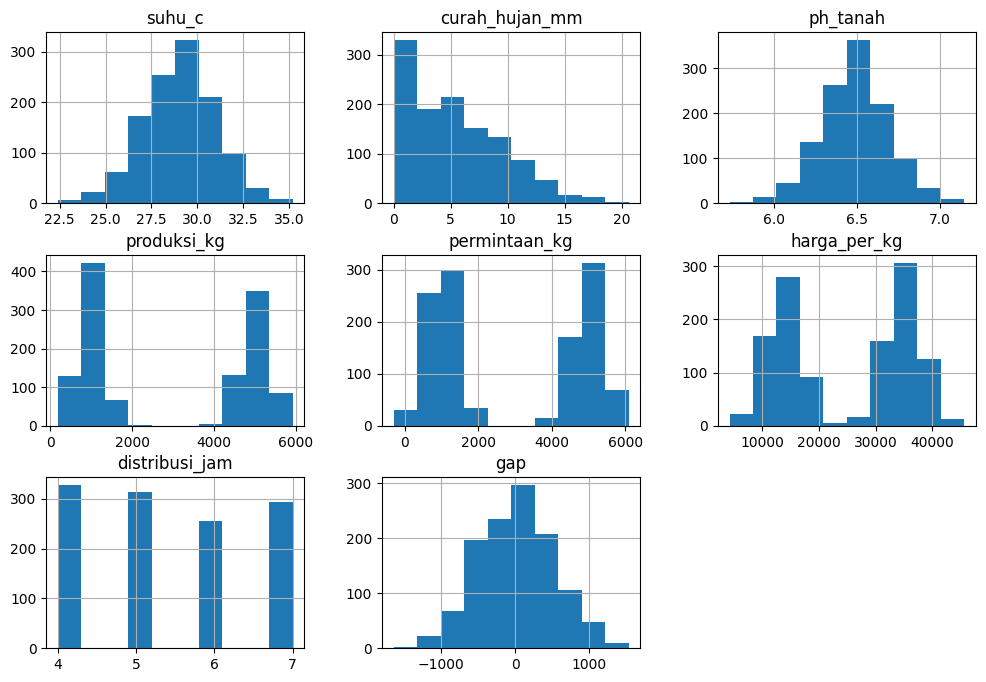

,produksi_kg,permintaan_kg,harga_per_kg
lokasi,,,
Malang,2952.593857,2958.020478,24829.523891
Semarang,2886.777409,2853.965116,24980.058140


In [28]:
# Distribusi fitur
df_clean.hist(figsize=(12,8))
plt.show()

# Statistik per wilayah
df_clean.groupby('lokasi')[['produksi_kg','permintaan_kg','harga_per_kg']].mean()

# **Data Cleaning**

Dilakukan:
- Imputasi missing value
- Penghapusan duplikasi
- Filtering nilai anomali

In [29]:
df_cleaned = df_raw.copy()

df_cleaned.fillna(df_cleaned.median(numeric_only=True), inplace=True)
df_cleaned.drop_duplicates(inplace=True)
df_cleaned = df_cleaned[df_cleaned['produksi_kg'] < 10000]

print("After cleaning:", df_cleaned.shape)

After cleaning: (1188, 10)


# **FEATURE ENGINEERING**

Membuat fitur "gap" sebagai selisih antara produksi dan permintaan.


In [30]:
df_cleaned['gap'] = df_cleaned['produksi_kg'] - df_cleaned['permintaan_kg']

# **VISUALISASI**

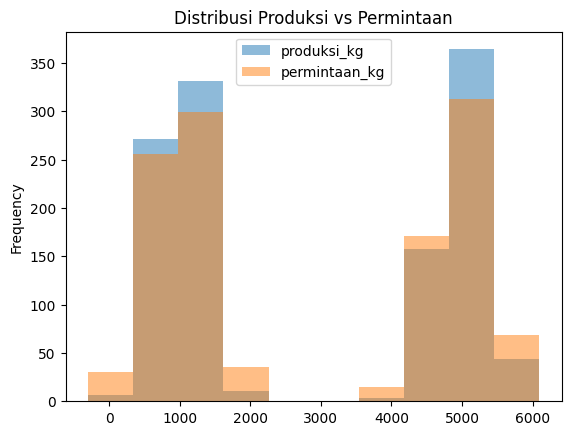

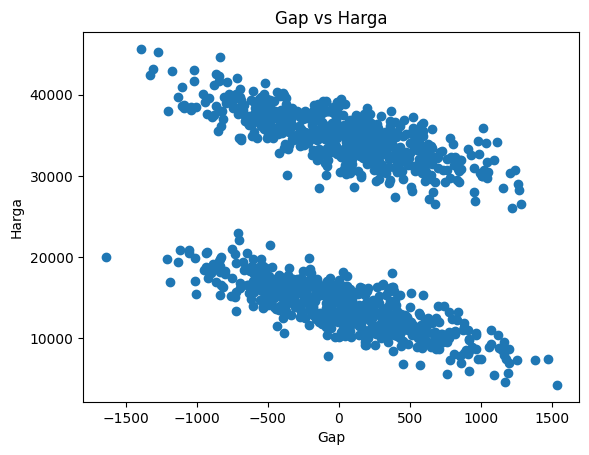

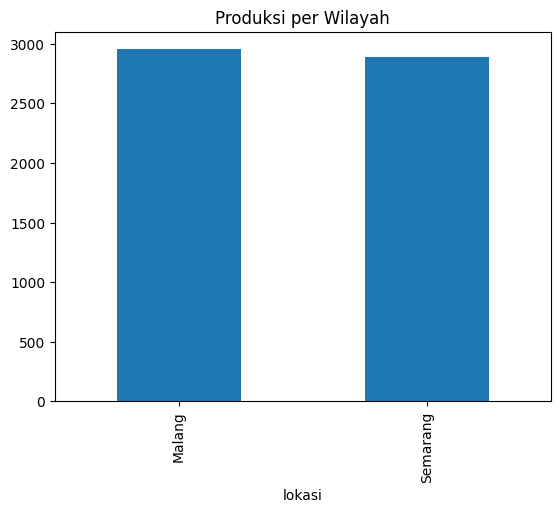

In [31]:
# Histogram
df_clean[['produksi_kg','permintaan_kg']].plot(kind='hist', alpha=0.5)
plt.title("Distribusi Produksi vs Permintaan")
plt.show()

# Scatter
plt.scatter(df_clean['gap'], df_clean['harga_per_kg'])
plt.title("Gap vs Harga")
plt.xlabel("Gap")
plt.ylabel("Harga")
plt.show()

# Bar
df_clean.groupby('lokasi')['produksi_kg'].mean().plot(kind='bar')
plt.title("Produksi per Wilayah")
plt.show()

# **CORRELATION ANALYSIS**

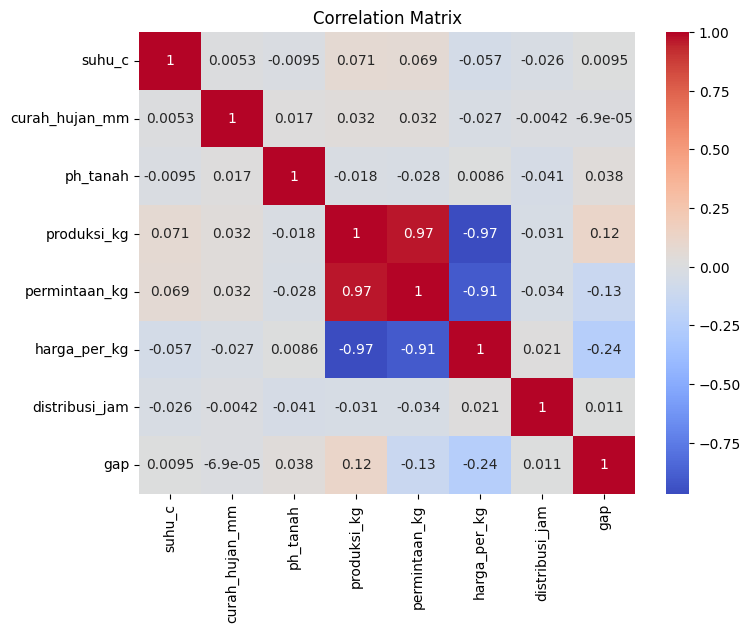

In [32]:
corr = df_clean.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# **DATA PREPARATION**

In [33]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(['harga_per_kg','tanggal'], axis=1)
y = df_clean['harga_per_kg']

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **MODEL TRAINING**

In [34]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Random Forest
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("RF RMSE:", rmse_rf)
print("RF R2:", r2_rf)

print("LR RMSE:", rmse_lr)
print("LR R2:", r2_lr)

RF RMSE: 2166.8774064568174
RF R2: 0.9611990024238266
LR RMSE: 1998.0178845839512
LR R2: 0.9670107113029465


# **MODEL COMPARISON**

In [35]:
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Linear Regression'],
    'RMSE': [rmse_rf, rmse_lr],
    'R2': [r2_rf, r2_lr]
})

comparison

,Model,RMSE,R2
0,Random Forest,2166.877406,0.961199
1,Linear Regression,1998.017885,0.967011


# **FEATURE IMPORTANCE**

In [36]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

importance.head(10)

,feature,importance
3,produksi_kg,0.344020
4,permintaan_kg,0.307447
8,komoditas_Padi,0.275260
6,gap,0.056587
1,curah_hujan_mm,0.004920
2,ph_tanah,0.004888
0,suhu_c,0.004617
5,distribusi_jam,0.001595
7,lokasi_Semarang,0.000667


# SIMULASI **PREDIKSI**

In [37]:
sample = X_test.iloc[[0]]
pred = rf.predict(sample)

print("Prediksi Harga:", int(pred[0]))

Prediksi Harga: 13349


# **Insight data-driven**

1. Ketika gap negatif besar (permintaan > produksi), harga meningkat signifikan
2. Produksi tinggi tidak menjamin harga stabil jika distribusi tidak optimal
3. Wilayah dengan distribusi cepat cenderung memiliki harga lebih stabil
4. Faktor lingkungan mempengaruhi produksi secara tidak langsung

# **Insight (Manual Analysis)**

1. Supply-demand gap merupakan faktor paling berpengaruh terhadap harga pangan.
2. Ketika permintaan lebih tinggi dibanding produksi, harga meningkat signifikan.
3. Distribusi logistik (durasi pengiriman) berkontribusi terhadap kenaikan harga.
4. Variasi produksi antar wilayah menunjukkan ketidakseimbangan distribusi.
5. Faktor lingkungan seperti suhu dan curah hujan mempengaruhi hasil produksi.

# **Insight Strategis**

1. Ketidak seimbangan supply-demand menyebabkan fluktuasi harga
2. Distribusi yang tidak efisien meningkatkan biaya
3. Faktor lingkungan mempengaruhi produksi
4. Sistem prediksi dapat membantu stabilisasi harga

# **Interpretasi Model**

- Gap supply-demand merupakan faktor utama yang mempengaruhi harga
- Permintaan memiliki pengaruh besar terhadap kenaikan harga
- Distribusi dan faktor lingkungan memperkuat dampak tersebut

# **Kesimpulan**

Model AI berhasil memprediksi harga dengan baik dan dapat digunakan untuk:
- Prediksi harga pangan
- Deteksi potensi oversupply/undersupply
- Mendukung pengambilan keputusan distribusi

Pendekatan ini mendukung konsep KatoNice sebagai platform berbasis AI untuk meningkatkan efisiensi rantai pasok agrikultur.

# **Implementasi Azure**

Solusi ini dapat diimplementasikan menggunakan:

1. Azure Machine Learning  
   - Training dan deployment model  
   - Monitoring performa model  

2. Azure Blob Storage  
   - Penyimpanan dataset  

3. Azure App Service  
   - API prediksi harga  

4. Azure Functions  
   - Prediksi real-time berbasis event  

Dengan ini, sistem dapat berjalan secara real-time dan scalable.